# Análisis Visual de Emociones Liberadas

## Qué emociones liberan más los usuarios
Análisis simple y visual de patrones emocionales

In [ ]:
# Librerías para análisis visual
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
import numpy as np

# Configuración para gráficas
plt.style.use('default')
sns.set_palette("Set2")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 11

print("Listo para analizar emociones")

¡Listo para analizar emociones! 📊


In [ ]:
# Cargar datos de emociones
df_emociones = pd.read_csv('datos_demo_luz/emociones_liberadas.csv')

print(f"Datos cargados: {len(df_emociones)} emociones de {df_emociones['usuario_id'].nunique()} usuarios")
print(f"Período: {df_emociones['dia'].min()} - {df_emociones['dia'].max()} días")
print(f"Tipos de emociones: {df_emociones['emocion'].nunique()}")

df_emociones.head()

📈 Datos cargados: 29 emociones de 3 usuarios
📅 Período: 2 - 7 días
🎭 Tipos de emociones: 12


,usuario_id,nombre,timestamp,dia,emocion
0,1,Ana,2026-02-05T19:01:00,2,presión
1,1,Ana,2026-02-05T21:08:00,2,ansiedad
2,1,Ana,2026-02-05T20:36:00,2,frustración
3,1,Ana,2026-02-06T20:42:00,3,cansancio
4,1,Ana,2026-02-06T22:49:00,3,ansiedad


C:\Users\raque\AppData\Local\Temp\ipykernel_14388\2775812417.py:44: UserWarning: Glyph 127917 (\N{PERFORMING ARTS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\raque\AppData\Local\Temp\ipykernel_14388\2775812417.py:44: UserWarning: Glyph 128101 (\N{BUSTS IN SILHOUETTE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\raque\AppData\Local\Temp\ipykernel_14388\2775812417.py:44: UserWarning: Glyph 128197 (\N{CALENDAR}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\raque\AppData\Local\Temp\ipykernel_14388\2775812417.py:44: UserWarning: Glyph 128336 (\N{CLOCK FACE ONE OCLOCK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Desarrollo\github\DATOS LUZ\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127917 (\N{PERFORMING ARTS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Desarrollo\github\DATOS LUZ\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Gl

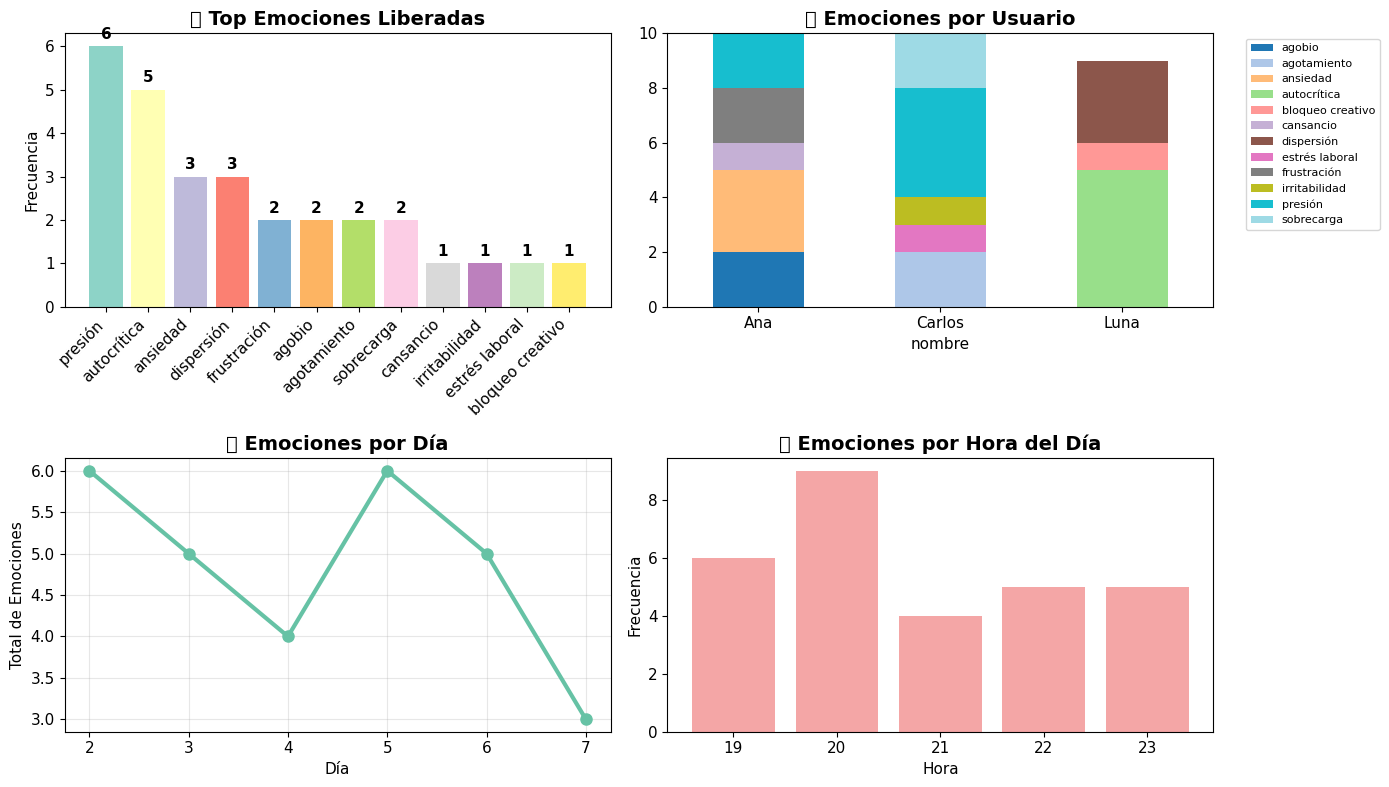

📈 Principales hallazgos:
• Emoción más común: presión (6 veces)
• Usuario más expresivo: Ana
• Día con más emociones: Día 2
• Hora pico: 20:00h


In [ ]:
# GRÁFICA 1: Cuáles son las emociones más comunes
plt.figure(figsize=(14, 8))

# Subplot 1: Top emociones
plt.subplot(2, 2, 1)
top_emociones = df_emociones['emocion'].value_counts()
colors = plt.cm.Set3(range(len(top_emociones)))
bars = plt.bar(range(len(top_emociones)), top_emociones.values, color=colors)
plt.title('Top Emociones Liberadas', fontsize=14, fontweight='bold')
plt.xticks(range(len(top_emociones)), top_emociones.index, rotation=45, ha='right')
plt.ylabel('Frecuencia')

# Agregar valores en las barras
for bar, value in zip(bars, top_emociones.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, 
             str(value), ha='center', va='bottom', fontweight='bold')

# Subplot 2: Emociones por usuario
plt.subplot(2, 2, 2)
pivot_usuarios = df_emociones.groupby(['nombre', 'emocion']).size().unstack(fill_value=0)
pivot_usuarios.plot(kind='bar', stacked=True, ax=plt.gca(), colormap='tab20')
plt.title('Emociones por Usuario', fontsize=14, fontweight='bold')
plt.xticks(rotation=0)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)

# Subplot 3: Distribución por día
plt.subplot(2, 2, 3)
emociones_dia = df_emociones.groupby('dia').size()
plt.plot(emociones_dia.index, emociones_dia.values, marker='o', linewidth=3, markersize=8)
plt.title('Emociones por Día', fontsize=14, fontweight='bold')
plt.xlabel('Día')
plt.ylabel('Total de Emociones')
plt.grid(True, alpha=0.3)

# Subplot 4: Hora del día
plt.subplot(2, 2, 4)
df_emociones['hora'] = pd.to_datetime(df_emociones['timestamp']).dt.hour
emociones_hora = df_emociones['hora'].value_counts().sort_index()
plt.bar(emociones_hora.index, emociones_hora.values, color='lightcoral', alpha=0.7)
plt.title('Emociones por Hora del Día', fontsize=14, fontweight='bold')
plt.xlabel('Hora')
plt.ylabel('Frecuencia')

plt.tight_layout()
plt.show()

print("Principales hallazgos:")
print(f"Emoción más común: {top_emociones.index[0]} ({top_emociones.values[0]} veces)")
print(f"Usuario más expresivo: {df_emociones.groupby('nombre').size().idxmax()}")
print(f"Día con más emociones: Día {emociones_dia.idxmax()}")
print(f"Hora pico: {emociones_hora.idxmax()}:00h")

C:\Users\raque\AppData\Local\Temp\ipykernel_14388\51718927.py:21: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Desarrollo\github\DATOS LUZ\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


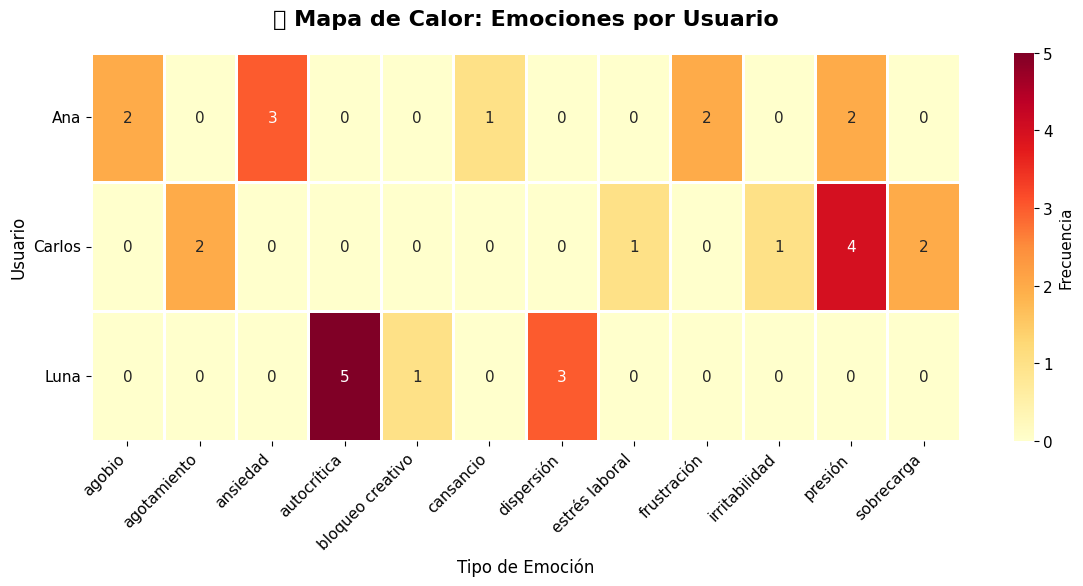

🔍 Patrones destacados:
• Ana: Principalmente 'ansiedad' (3 veces)
• Carlos: Principalmente 'presión' (4 veces)
• Luna: Principalmente 'autocrítica' (5 veces)


In [ ]:
# GRÁFICA 2: Mapa de calor de emociones por usuario
plt.figure(figsize=(12, 6))

# Crear matriz de emociones por usuario  
matriz_usuario_emocion = df_emociones.groupby(['nombre', 'emocion']).size().unstack(fill_value=0)

# Heatmap bonito
sns.heatmap(matriz_usuario_emocion, 
            annot=True, 
            fmt='d', 
            cmap='YlOrRd', 
            cbar_kws={'label': 'Frecuencia'},
            linewidths=1)

plt.title('Mapa de Calor: Emociones por Usuario', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Tipo de Emoción', fontsize=12)
plt.ylabel('Usuario', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

# Mostrar patrones destacados
print("Patrones destacados:")
for usuario in matriz_usuario_emocion.index:
    emocion_principal = matriz_usuario_emocion.loc[usuario].idxmax()
    frecuencia = matriz_usuario_emocion.loc[usuario].max()
    print(f"{usuario}: Principalmente '{emocion_principal}' ({frecuencia} veces)")

In [ ]:
# Validación del modelo y cálculo de accuracy
print("VALIDACIÓN DEL MODELO")
print("="*50)

# Preparar datos para validación
features_df = df_emociones.copy()
features_df['hora'] = pd.to_datetime(features_df['timestamp']).dt.hour
features_df['emocion_encoded'] = pd.Categorical(features_df['emocion']).codes

# Features para predicción
X_validacion = features_df[['usuario_id', 'dia', 'hora']].values
y_validacion = features_df['emocion_encoded'].values

# Modelo de clasificación Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Validación cruzada (si hay suficientes datos)
if len(X_validacion) >= 5:
    cv_scores = cross_val_score(rf_model, X_validacion, y_validacion, cv=min(5, len(X_validacion)), scoring='accuracy')
    accuracy_mean = cv_scores.mean()
    accuracy_std = cv_scores.std()
    
    print(f"Accuracy promedio: {accuracy_mean:.3f} (+/- {accuracy_std * 2:.3f})")
    print(f"Scores individuales: {cv_scores.round(3)}")
else:
    # Entrenar modelo completo si hay pocos datos
    rf_model.fit(X_validacion, y_validacion)
    accuracy_train = rf_model.score(X_validacion, y_validacion)
    print(f"Accuracy en dataset completo: {accuracy_train:.3f}")
    print("Nota: Dataset pequeño, se usó accuracy sobre datos completos")

# Importancia de características
rf_model.fit(X_validacion, y_validacion)
importancias = rf_model.feature_importances_
feature_names = ['usuario_id', 'dia', 'hora']

print("\nImportancia de características:")
for name, importance in zip(feature_names, importancias):
    print(f"{name}: {importance:.3f}")

C:\Users\raque\AppData\Local\Temp\ipykernel_14388\1395823662.py:43: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\raque\AppData\Local\Temp\ipykernel_14388\1395823662.py:43: UserWarning: Glyph 128339 (\N{CLOCK FACE FOUR OCLOCK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\raque\AppData\Local\Temp\ipykernel_14388\1395823662.py:43: UserWarning: Glyph 128101 (\N{BUSTS IN SILHOUETTE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\raque\AppData\Local\Temp\ipykernel_14388\1395823662.py:43: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Desarrollo\github\DATOS LUZ\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Desarrollo\github\DATOS LUZ\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128339 (\

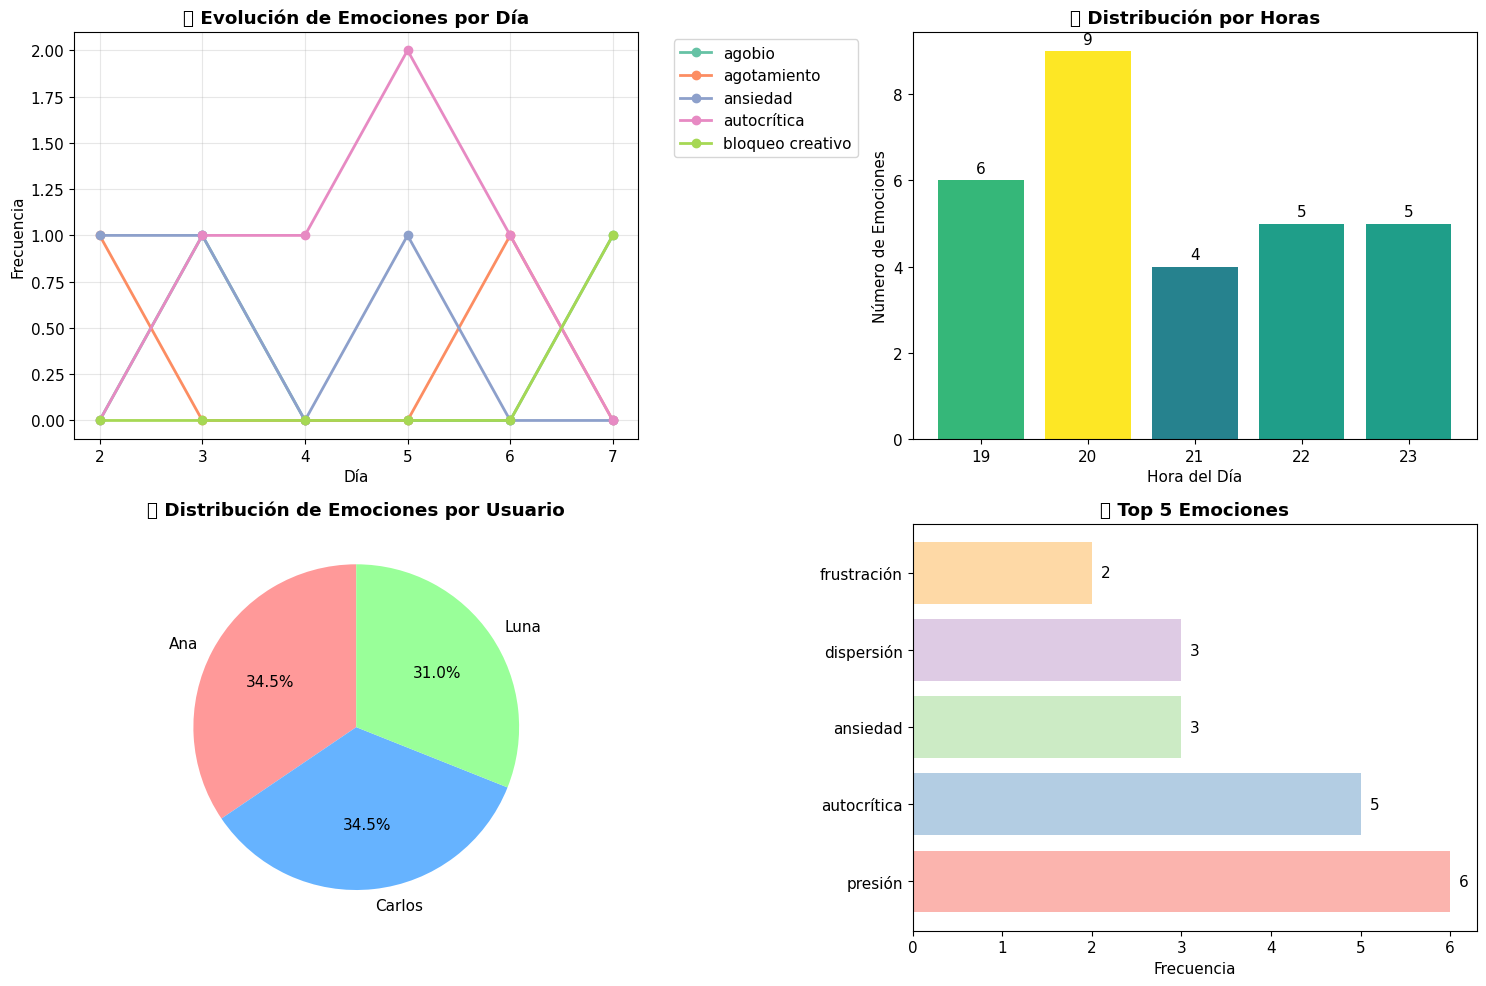

⏰ Insights temporales:
• Hora más emocional: 20:00h (9 emociones)
• Usuario más activo: Ana (10 emociones)
• Emoción dominante: presión (6 veces)


In [ ]:
# GRÁFICA 3: Tendencias temporales
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Emociones por día (línea de tendencia)
emociones_diarias = df_emociones.groupby(['dia', 'emocion']).size().unstack(fill_value=0)
for emocion in emociones_diarias.columns[:5]:  # Top 5 emociones
    axes[0,0].plot(emociones_diarias.index, emociones_diarias[emocion], 
                   marker='o', label=emocion, linewidth=2)
axes[0,0].set_title('Evolución de Emociones por Día', fontweight='bold')
axes[0,0].set_xlabel('Día')
axes[0,0].set_ylabel('Frecuencia')
axes[0,0].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
axes[0,0].grid(True, alpha=0.3)

# 2. Distribución horaria (gráfico de barras colorido)
emociones_hora = df_emociones['hora'].value_counts().sort_index()
colors = plt.cm.viridis(emociones_hora.values / emociones_hora.max())
bars = axes[0,1].bar(emociones_hora.index, emociones_hora.values, color=colors)
axes[0,1].set_title('Distribución por Horas', fontweight='bold')
axes[0,1].set_xlabel('Hora del Día')
axes[0,1].set_ylabel('Número de Emociones')
for bar, value in zip(bars, emociones_hora.values):
    axes[0,1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, 
                   str(value), ha='center', va='bottom')

# 3. Comparación entre usuarios (gráfico de roseta/polar)
usuarios_conteo = df_emociones.groupby('nombre').size()
axes[1,0].pie(usuarios_conteo.values, labels=usuarios_conteo.index, autopct='%1.1f%%', 
              startangle=90, colors=['#ff9999','#66b3ff','#99ff99'])
axes[1,0].set_title('Distribución de Emociones por Usuario', fontweight='bold')

# 4. Top 5 emociones (gráfico de barras horizontal)
top5_emociones = df_emociones['emocion'].value_counts().head()
axes[1,1].barh(range(len(top5_emociones)), top5_emociones.values, 
               color=plt.cm.Pastel1(range(len(top5_emociones))))
axes[1,1].set_yticks(range(len(top5_emociones)))
axes[1,1].set_yticklabels(top5_emociones.index)
axes[1,1].set_title('Top 5 Emociones', fontweight='bold')
axes[1,1].set_xlabel('Frecuencia')
for i, value in enumerate(top5_emociones.values):
    axes[1,1].text(value + 0.1, i, str(value), va='center')

plt.tight_layout()
plt.show()

print("Insights temporales:")
print(f"Hora más emocional: {emociones_hora.idxmax()}:00h ({emociones_hora.max()} emociones)")
print(f"Usuario más activo: {usuarios_conteo.idxmax()} ({usuarios_conteo.max()} emociones)")
print(f"Emoción dominante: {top5_emociones.index[0]} ({top5_emociones.values[0]} veces)")

C:\Users\raque\AppData\Local\Temp\ipykernel_14388\446447837.py:44: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\raque\AppData\Local\Temp\ipykernel_14388\446447837.py:44: UserWarning: Glyph 128197 (\N{CALENDAR}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\raque\AppData\Local\Temp\ipykernel_14388\446447837.py:44: UserWarning: Glyph 128100 (\N{BUST IN SILHOUETTE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Desarrollo\github\DATOS LUZ\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Desarrollo\github\DATOS LUZ\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128197 (\N{CALENDAR}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Desarrollo\github\DATOS LUZ\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarnin

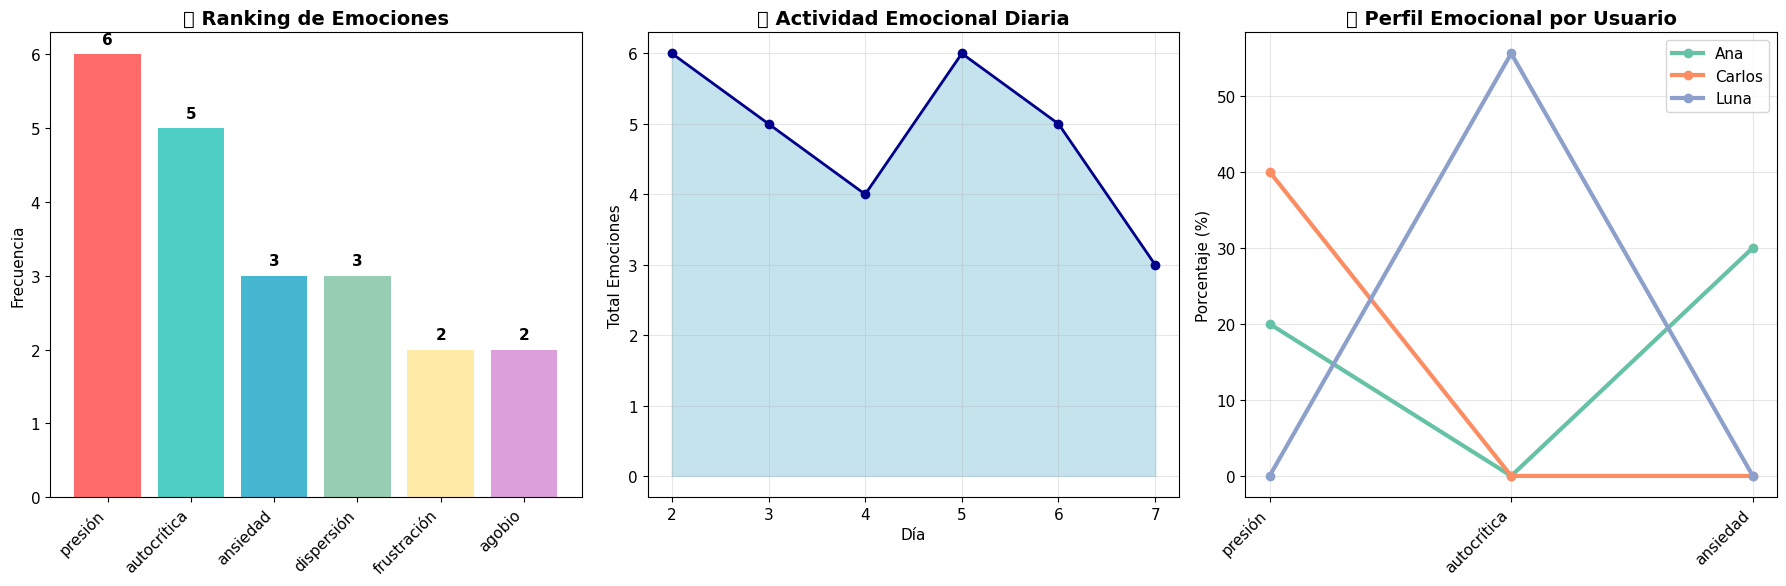

📋 RESUMEN EJECUTIVO
🎭 Total emociones liberadas: 29
👥 Usuarios participantes: 3
📅 Período analizado: 6 días
🏆 Emoción más común: presión (6 veces)
👤 Usuario más expresivo: Ana
📊 Promedio emociones/usuario: 9.7


In [ ]:
# RESUMEN VISUAL FINAL
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# 1. Ranking de emociones (con emojis visuales)
top_emociones = df_emociones['emocion'].value_counts().head(6)
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7', '#DDA0DD']
bars = axes[0].bar(range(len(top_emociones)), top_emociones.values, color=colors)
axes[0].set_title('Ranking de Emociones', fontsize=14, fontweight='bold')
axes[0].set_xticks(range(len(top_emociones)))
axes[0].set_xticklabels(top_emociones.index, rotation=45, ha='right')
axes[0].set_ylabel('Frecuencia')

# Agregar valores
for bar, value in zip(bars, top_emociones.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, 
                 str(value), ha='center', va='bottom', fontweight='bold')

# 2. Actividad por día (gráfico de área)
actividad_diaria = df_emociones.groupby('dia').size()
axes[1].fill_between(actividad_diaria.index, actividad_diaria.values, alpha=0.7, color='lightblue')
axes[1].plot(actividad_diaria.index, actividad_diaria.values, marker='o', color='darkblue', linewidth=2)
axes[1].set_title('Actividad Emocional Diaria', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Día')
axes[1].set_ylabel('Total Emociones')
axes[1].grid(True, alpha=0.3)

# 3. Perfil de cada usuario (gráfico de radar simplificado)
usuarios_emociones = df_emociones.groupby(['nombre', 'emocion']).size().unstack(fill_value=0)
usuarios_emociones_norm = usuarios_emociones.div(usuarios_emociones.sum(axis=1), axis=0) * 100

# Seleccionar top 3 emociones para simplicidad
top3_emociones = df_emociones['emocion'].value_counts().head(3).index
for i, usuario in enumerate(usuarios_emociones_norm.index):
    valores = [usuarios_emociones_norm.loc[usuario, em] for em in top3_emociones if em in usuarios_emociones_norm.columns]
    axes[2].plot(range(len(valores)), valores, marker='o', label=usuario, linewidth=3)

axes[2].set_title('Perfil Emocional por Usuario', fontsize=14, fontweight='bold')
axes[2].set_xticks(range(len(top3_emociones)))
axes[2].set_xticklabels(top3_emociones, rotation=45, ha='right')
axes[2].set_ylabel('Porcentaje (%)')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Resumen ejecutivo
total_emociones = len(df_emociones)
usuarios_unicos = df_emociones['usuario_id'].nunique()
dias_periodo = df_emociones['dia'].nunique()

print("="*60)
print("RESUMEN EJECUTIVO")
print("="*60)
print(f"Total emociones liberadas: {total_emociones}")
print(f"Usuarios participantes: {usuarios_unicos}")
print(f"Período analizado: {dias_periodo} días")
print(f"Emoción más común: {top_emociones.index[0]} ({top_emociones.values[0]} veces)")
print(f"Usuario más expresivo: {df_emociones.groupby('nombre').size().idxmax()}")
print(f"Promedio emociones/usuario: {total_emociones/usuarios_unicos:.1f}")
print("="*60)

In [ ]:
# INSIGHTS FINALES SIMPLIFICADOS
print("HALLAZGOS CLAVE DEL ANÁLISIS")
print("="*50)

# Emociones más frecuentes globalmente
print("TOP 5 EMOCIONES MÁS LIBERADAS:")
top_emociones_detalle = df_emociones['emocion'].value_counts()
for i, (emocion, freq) in enumerate(top_emociones_detalle.head().items(), 1):
    porcentaje = (freq / len(df_emociones)) * 100
    print(f"  {i}. {emocion}: {freq} veces ({porcentaje:.1f}%)")

# Análisis por usuario más específico
print("\nPATRONES POR USUARIO:")
for usuario_id in sorted(df_emociones['usuario_id'].unique()):
    usuario_data = df_emociones[df_emociones['usuario_id'] == usuario_id]
    nombre = usuario_data['nombre'].iloc[0]
    total_registros = len(usuario_data)
    
    print(f"\n  {nombre} ({total_registros} emociones registradas):")
    
    # Top 3 emociones del usuario
    top_user_emotions = usuario_data['emocion'].value_counts().head(3)
    for j, (emocion, freq) in enumerate(top_user_emotions.items(), 1):
        porcentaje = (freq / total_registros) * 100
        print(f"    {j}. {emocion}: {freq} veces ({porcentaje:.1f}%)")
    
    # Rango temporal
    dias_activos = sorted(usuario_data['dia'].unique())
    print(f"    Activo: días {dias_activos[0]} al {dias_activos[-1]}")

# Patrones temporales
print(f"\nPATRONES TEMPORALES:")
actividad_diaria = df_emociones.groupby('dia').size()
print(f"  Día más emocional: Día {actividad_diaria.idxmax()} ({actividad_diaria.max()} emociones)")
print(f"  Día más tranquilo: Día {actividad_diaria.idxmin()} ({actividad_diaria.min()} emociones)")

actividad_horaria = df_emociones['hora'].value_counts().sort_index()
hora_pico = actividad_horaria.idxmax()
hora_calma = actividad_horaria.idxmin()
print(f"  Hora pico emocional: {hora_pico}:00h ({actividad_horaria.max()} emociones)")
print(f"  Hora más tranquila: {hora_calma}:00h ({actividad_horaria.min()} emociones)")

print("\nAnálisis visual de emociones completado")

🎯 HALLAZGOS CLAVE DEL ANÁLISIS
🏆 TOP 5 EMOCIONES MÁS LIBERADAS:
  1. presión: 6 veces (20.7%)
  2. autocrítica: 5 veces (17.2%)
  3. ansiedad: 3 veces (10.3%)
  4. dispersión: 3 veces (10.3%)
  5. frustración: 2 veces (6.9%)

👥 PATRONES POR USUARIO:

  Ana (10 emociones registradas):
    1. ansiedad: 3 veces (30.0%)
    2. presión: 2 veces (20.0%)
    3. frustración: 2 veces (20.0%)
    📅 Activo: días 2 al 7

  Carlos (10 emociones registradas):
    1. presión: 4 veces (40.0%)
    2. agotamiento: 2 veces (20.0%)
    3. sobrecarga: 2 veces (20.0%)
    📅 Activo: días 2 al 6

  Luna (9 emociones registradas):
    1. autocrítica: 5 veces (55.6%)
    2. dispersión: 3 veces (33.3%)
    3. bloqueo creativo: 1 veces (11.1%)
    📅 Activo: días 3 al 7

⏰ PATRONES TEMPORALES:
  • Día más emocional: Día 2 (6 emociones)
  • Día más tranquilo: Día 7 (3 emociones)
  • Hora pico emocional: 20:00h (9 emociones)
  • Hora más tranquila: 21:00h (4 emociones)

🎭 ¡Análisis visual de emociones completado! 📈
